# The Perceptron

The perceptron simply calculates a weighted sum over the input and applies a step function to that sum and outputs the result.

The following figures illustrates the architecture of the perceptron:

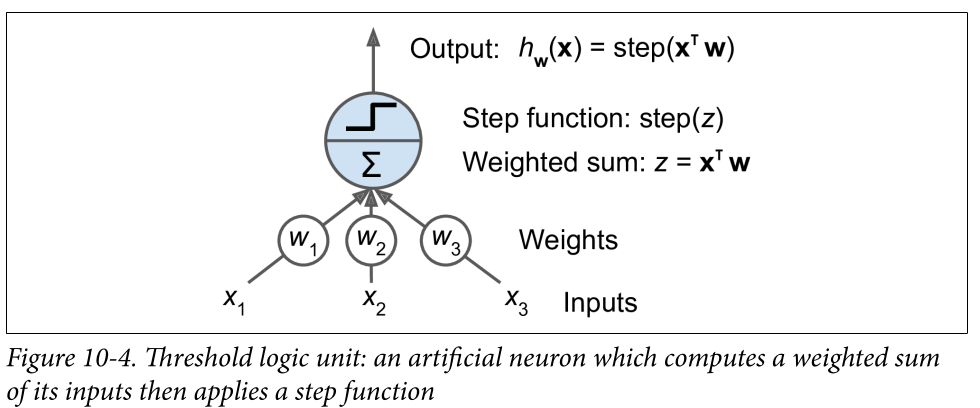

The most common activation functions for perceptrons are:

1. The heaviside function: <br>
    output = 0 if input < 0 <br>
    output = 1 if input >= 0 <br>

2. The sign function: <br>
    output = -1 if input < 0 <br>
    output = 0 if input = 0 <br>
    output = 1 if input > 0 <br>

Training the perceptron means finding the proper values of the weights (w0, w1, ... wn) so that the error is as low as possible.


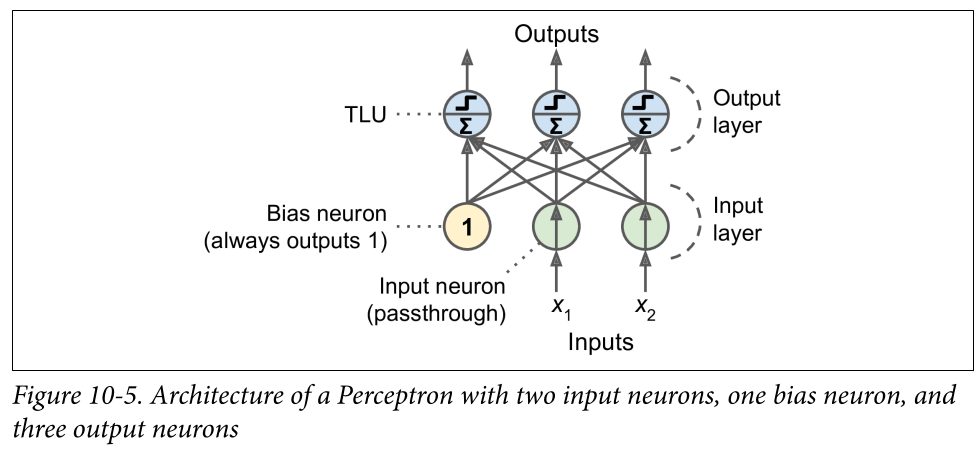

The following equation is used to calculate the output of all neurons:

$h_{W, b}(X) = \phi(XW + b)$

Where:<br>
X = A matrix of the input features. <br>
W = A matrix of all the weight connections, except for the bias. <br>
b = The bias weight. <br>
$\phi$ = The activation function.

The weight update rule for the perceptron is:

$W_{i, j}^{(next\ step)} = W_{i, j} + \eta(y_j - \hat{y_j})X_i$

In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron

iris = load_iris()
X = iris.data[:, (2, 3)] #petal length, petal width
y = (iris.target == 0).astype(int) #iris setosa?

per_clf = Perceptron()
per_clf.fit(X, y)
y_pred = per_clf.predict([[2, 0.5]])
y_pred

array([0])

Perceptrons are capable of outputting only integers, not probabilities like logistic regression. Therefore, logistic regression is preferred to Perceptrons.

## Multilayer Perceptron and Backpropagation

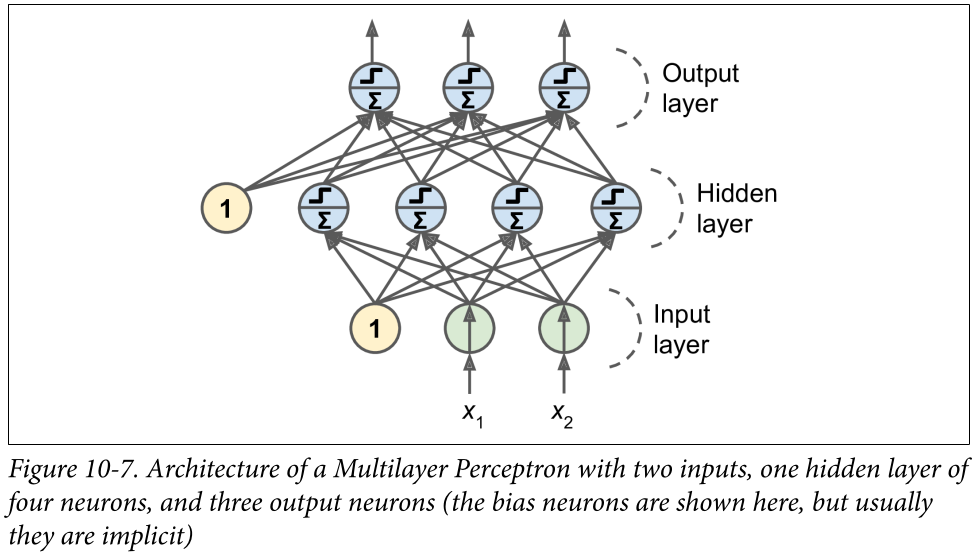

Backpropagation is used to efficiently calculate the contribution of each weight and bias to the error produced by then network when it makes its predictions. The algorithm calculates the gradients efficiently in order to apply one gradient descent step on the weights to push them towards a region in multidimensional space that produces less error than before. 

The algorithm works as follows:

1. Calculate the output of the network by passing the input through all the layers until it reaches the final layer (the output is calculated while saving the intermediate outputs as they are needed for the next steps).
2. Calculate the error that the network produced by using a cost function that compares the desired output with the output the network has given. 
3. Calculate the contributions to the error by each weight and bias from the previous layer using the chain rule. We do this repeatedly until we reach the input layer.
4. Use the gradient calculated to perform a single gradient descent step to tweak all the connection weights in the network. 

__Note:__ It is important to randomly initialize the weights of the network to break any symmetries in the neurons. Symmetries make a large network with hundreds of layers and neurons behave as if it has less neurons than it actually does. Therefore, random initialization is important!

# Implementing MLPs with Keras

Keras uses different computation backends depending on the implementation. It can use either Tensorflow, Microsoft Cognitive Toolkit (CNTK), and Theano. 

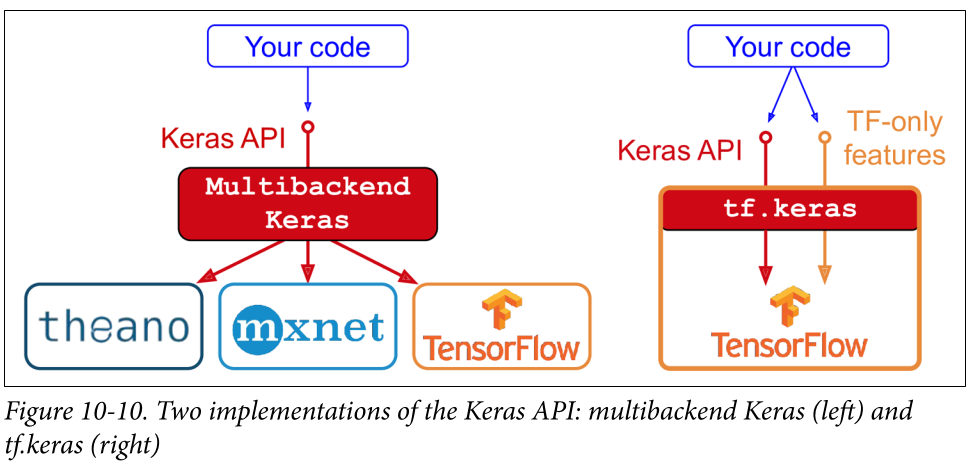

# Building an Image Classifier using the Sequential API

In [1]:
import tensorflow as tf
import keras

2024-08-31 16:48:20.638043: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-31 16:48:20.654373: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-31 16:48:20.659405: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-08-31 16:48:20.671255: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-08-31 16:48:21.318655: W tensorflow/compiler/tf2

In [2]:
fashion_mnist = keras.datasets.fashion_mnist

In [3]:
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

In [4]:
X_train_full.shape

(60000, 28, 28)

In [5]:
# scale the features to be between 0 and 1
# and create a validation set

X_valid, X_train = X_train_full[:5000]/255.0, X_train_full[5000:]/255.0
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test/255.0

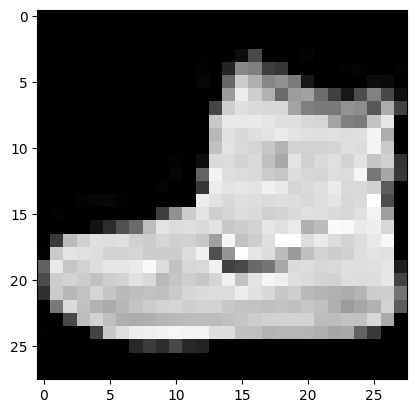

In [6]:
from matplotlib import pyplot as plt
plt.imshow(X_valid[0], cmap = plt.cm.gray)
plt.show()

In [7]:
class_names = [
    'T-shirt/top',
    'Trouser', 
    'Pullover', 
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle Boot'
]

In [8]:
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape = [28, 28]))
model.add(keras.layers.Dense(300, activation = 'relu'))
model.add(keras.layers.Dense(100, activation = 'relu'))
model.add(keras.layers.Dense(10, activation = 'softmax'))

/home/thoalfeqar/miniconda3/envs/tf/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2024-08-30 20:57:02.708988: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error
2024-08-30 20:57:02.709018: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:135] retrieving CUDA diagnostic information for host: thoalfeqar-System-Product-Name
2024-08-30 20:57:02.709025: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:142] hostname: thoalfeqar-System-Product-Name
2024-08-30 20:57:02.709087: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:166] libcuda reported version is: 535.183.1
2024-08-30 20:57:02.709106: I external/local_xla/xla/stream_executor/cud

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [11]:
hidden1 = model.layers[1]
hidden1.name

'dense'

In [12]:
model.get_layer('dense') is hidden1

True

In [13]:
weights, biases = hidden1.get_weights()

In [14]:
weights, biases

(array([[ 0.07293302,  0.04357641, -0.03603083, ..., -0.04223592,
         -0.06743166,  0.01989038],
        [ 0.0149316 ,  0.01850566,  0.04532029, ..., -0.00589262,
          0.01005665,  0.01476102],
        [-0.06657428, -0.02161067, -0.03834999, ...,  0.05673246,
         -0.00760617,  0.00781853],
        ...,
        [-0.0576291 ,  0.02767767, -0.00466578, ...,  0.0686571 ,
          0.05033891,  0.02901299],
        [ 0.00030804,  0.03147082, -0.04335866, ..., -0.00768574,
          0.04243531, -0.01511427],
        [ 0.03976832, -0.00681018,  0.0617992 , ..., -0.04237014,
          0.07261625, -0.0412803 ]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.

In [15]:
weights.shape

(784, 300)

In [16]:
biases.shape

(300,)

In [17]:
model.compile(loss = 'sparse_categorical_crossentropy', optimizer = 'sgd', metrics = ['accuracy'])

In [18]:
history = model.fit(X_train, y_train, epochs = 30, validation_data = (X_valid, y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 989us/step - accuracy: 0.6879 - loss: 0.9990 - val_accuracy: 0.8300 - val_loss: 0.5123
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 937us/step - accuracy: 0.8281 - loss: 0.4972 - val_accuracy: 0.8468 - val_loss: 0.4602
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 955us/step - accuracy: 0.8437 - loss: 0.4497 - val_accuracy: 0.8526 - val_loss: 0.4252
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 954us/step - accuracy: 0.8500 - loss: 0.4228 - val_accuracy: 0.8568 - val_loss: 0.4185
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8602 - loss: 0.3925 - val_accuracy: 0.8702 - val_loss: 0.3816
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 961us/step - accuracy: 0.8653 - loss: 0.3818 - val_accuracy: 0.8724 - val_loss: 0.3661
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 983us/step - accuracy: 0.8702 - loss: 0.3644 - val_accuracy: 0.8748 - val_loss: 0.3538
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8732 - los

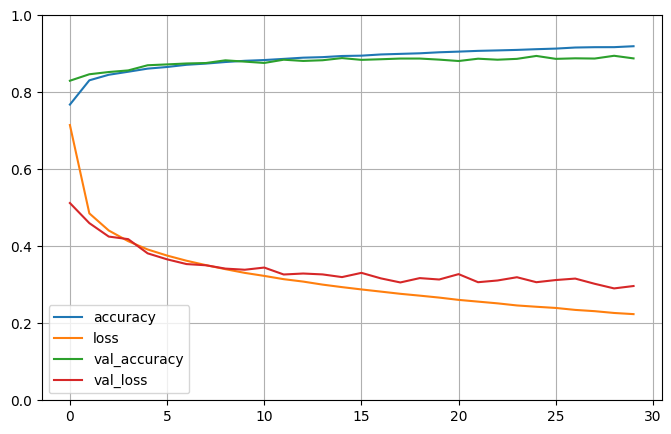

In [19]:
import pandas as pd
pd.DataFrame(history.history).plot(figsize = (8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

In [20]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step - accuracy: 0.8792 - loss: 0.3360


[0.329336553812027, 0.8791000247001648]

## Building complex models using the functional API

Let us implement the following architecture:

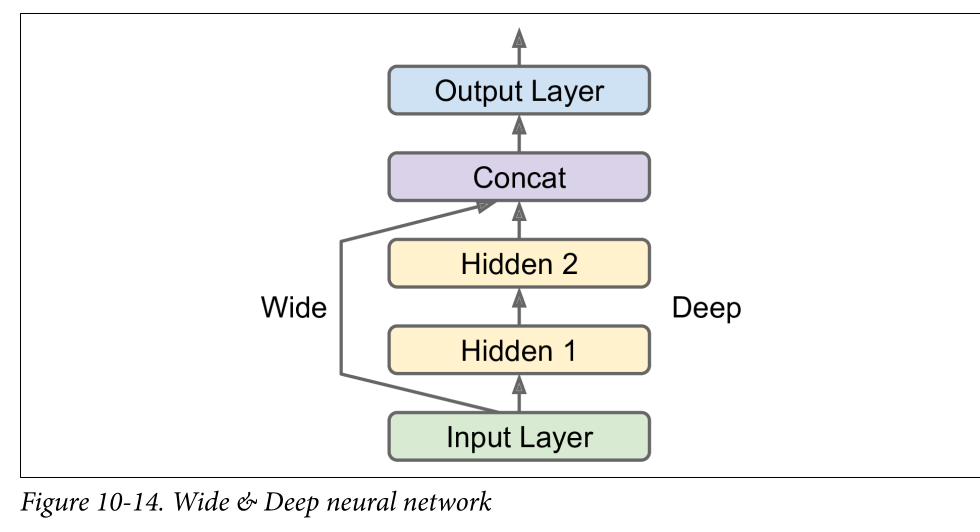

In [21]:
input_ = keras.layers.Input(shape = X_train.shape[1:])
flatten = keras.layers.Flatten()(input_)
hidden1 = keras.layers.Dense(30, activation = 'relu')(flatten)
hidden2 = keras.layers.Dense(30, activation = 'relu')(hidden1)
concat = keras.layers.Concatenate()([flatten, hidden2])
output = keras.layers.Dense(10, activation = 'softmax')(concat)
model = keras.Model(inputs = [input_], outputs = [output])

In [22]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 28, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 784)       │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 30)        │     23,550 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 30)        │        930 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 814)       │          0 │ flatten_1[0][0],  │
│ (Concatenate)       │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 10)        │      8,150 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 32,630 (127.46 KB)

 Trainable params: 32,630 (127.46 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(loss = 'sparse_categorical_crossentropy', optimizer = 'sgd', metrics = ['accuracy'])

In [24]:
model.fit(X_train, y_train, epochs = 30, validation_data = [X_valid, y_valid])

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 824us/step - accuracy: 0.6551 - loss: 1.1005 - val_accuracy: 0.8002 - val_loss: 0.6088
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 687us/step - accuracy: 0.8031 - loss: 0.5898 - val_accuracy: 0.8250 - val_loss: 0.5335
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 709us/step - accuracy: 0.8244 - loss: 0.5226 - val_accuracy: 0.8312 - val_loss: 0.4939
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 698us/step - accuracy: 0.8319 - loss: 0.4913 - val_accuracy: 0.8424 - val_loss: 0.4656
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 731us/step - accuracy: 0.8363 - loss: 0.4694 - val_accuracy: 0.8476 - val_loss: 0.4522
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 720us/step - accuracy: 0.8427 - loss: 0.4458 - val_accuracy: 0.8508 - val_loss: 0.4384
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 746us/step - accuracy: 0.8454 - loss: 0.4416 - val_accuracy: 0.8528 - val_loss: 0.4281
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 706us/step - accuracy: 0.8475 -

## Splitting the features input different subsets

You can also split the input features and pass them as two separate input or more. Each subset of the features can be treated differently from other subsets. The following architecture illustrates this:

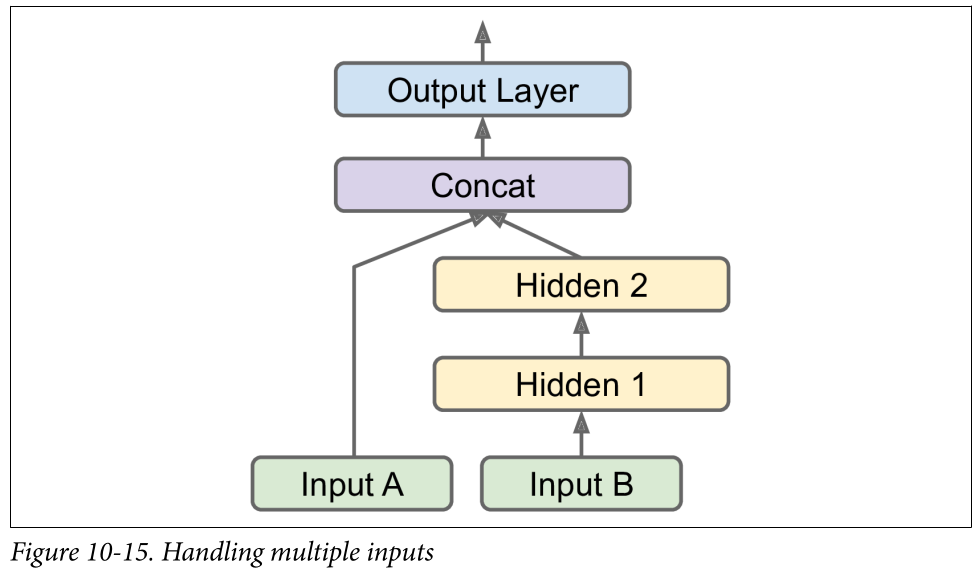

In [25]:
input_A = keras.layers.Input(shape = [28, 14], name = 'wide_input')
input_B = keras.layers.Input(shape = [28, 28], name = 'deep_input')
flattenB = keras.layers.Flatten()(input_B)
flattenA = keras.layers.Flatten()(input_A)
hidden1 = keras.layers.Dense(30, activation = 'relu')(flattenB)
hidden2 = keras.layers.Dense(30, activation = 'relu')(hidden1)
concat = keras.layers.concatenate([flattenA, flattenB])
output = keras.layers.Dense(10, activation = 'softmax')(concat)
model = keras.models.Model(inputs = [input_A, input_B], outputs = [output])

In [26]:
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ wide_input          │ (None, 28, 14)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ deep_input          │ (None, 28, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 392)       │          0 │ wide_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 784)       │          0 │ deep_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 1176)      │          0 │ flatten_3[0][0],  │
│ (Concatenate)       │                   │            │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 10)        │     11,770 │ concatenate_1[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,770 (45.98 KB)

 Trainable params: 11,770 (45.98 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
X_train_A, X_train_B = X_train[:, :, :14], X_train
X_valid_A, X_valid_B = X_valid[:, :, :14], X_valid
X_test_A, X_test_B = X_test[:, :, :14], X_test

In [28]:
model.compile(loss = 'sparse_categorical_crossentropy', optimizer = 'sgd', metrics = ['accuracy'])

In [29]:
model.fit((X_train_A, X_train_B), y_train, epochs = 30,
          validation_data = ((X_valid_A, X_valid_B), y_valid))


Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 594us/step - accuracy: 0.6775 - loss: 1.0230 - val_accuracy: 0.8116 - val_loss: 0.5992
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 534us/step - accuracy: 0.8096 - loss: 0.5844 - val_accuracy: 0.8266 - val_loss: 0.5392
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 539us/step - accuracy: 0.8260 - loss: 0.5346 - val_accuracy: 0.8398 - val_loss: 0.5037
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 541us/step - accuracy: 0.8300 - loss: 0.5039 - val_accuracy: 0.8438 - val_loss: 0.4859
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 547us/step - accuracy: 0.8355 - loss: 0.4819 - val_accuracy: 0.8458 - val_loss: 0.4751
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 519us/step - accuracy: 0.8384 - loss: 0.4776 - val_accuracy: 0.8478 - val_loss: 0.4642
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 525us/step - accuracy: 0.8446 - loss: 0.4663 - val_accuracy: 0.8502 - val_loss: 0.4593
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 544us/step - accuracy: 0.8462 -

In [30]:
model.evaluate((X_test_A, X_test_B), y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 410us/step - accuracy: 0.8428 - loss: 0.4444


[0.44944170117378235, 0.8413000106811523]

## Using the Subclassing API to Build Dynamic Models

The Sequential model and the Functional API are both static, which means that the whole model is just a static graph of layers that don't change during execution. On the other hand, the subclassing API allows for dynamic behavior such as conditional branching and loops. 

In [58]:
@keras.saving.register_keras_serializable()
class WideAndDeepModel(keras.Model):
    def __init__(self, units = 30, activation = 'relu', **kwargs):
        super().__init__(**kwargs)
        self.flatten = keras.layers.Flatten()
        self.hidden1 = keras.layers.Dense(units, activation=activation)
        self.hidden2 = keras.layers.Dense(units, activation=activation)
        self.main_output = keras.layers.Dense(10, activation = 'softmax')

    def __call__(self, inputs):
        input_A, input_B = inputs
        flattenA = self.flatten(input_A)
        flattenB = self.flatten(input_B)
        hidden1 = self.hidden1(flattenB)
        hidden2 = self.hidden2(hidden1)
        concat = keras.layers.concatenate([flattenA, hidden2])
        output = self.main_output(concat)
        return output

model = WideAndDeepModel()


In [59]:
model.compile(loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [60]:
model.fit((X_train_A, X_train_B), y_train, epochs = 30, validation_data = ((X_valid_A, X_valid_B), y_valid))


Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 810us/step - accuracy: 0.7370 - loss: 0.7495 - val_accuracy: 0.8526 - val_loss: 0.4280
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 762us/step - accuracy: 0.8466 - loss: 0.4357 - val_accuracy: 0.8404 - val_loss: 0.4575
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 767us/step - accuracy: 0.8592 - loss: 0.3935 - val_accuracy: 0.8608 - val_loss: 0.3898
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 772us/step - accuracy: 0.8669 - loss: 0.3717 - val_accuracy: 0.8628 - val_loss: 0.4077
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 772us/step - accuracy: 0.8741 - loss: 0.3561 - val_accuracy: 0.8734 - val_loss: 0.3662
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 752us/step - accuracy: 0.8786 - loss: 0.3425 - val_accuracy: 0.8704 - val_loss: 0.3675
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 701us/step - accuracy: 0.8823 - loss: 0.3327 - val_accuracy: 0.8714 - val_loss: 0.3770
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 773us/step - accuracy: 0.8853 -

## Saving and Restoring a Model

In [61]:
model.save('models/my_keras_model.keras')

In [62]:
loaded_model = keras.models.load_model('models/my_keras_model.keras')
loaded_model.evaluate((X_test_A, X_test_B), y_test)

/home/thoalfeqar/miniconda3/envs/tf/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 8 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 467us/step - accuracy: 0.1257 - loss: 2.4962


[2.498131036758423, 0.12349999696016312]

## Using Callbacks

In [8]:
checkpoint_callback = keras.callbacks.ModelCheckpoint('models/my_keras_model.keras', save_best_only = True)

model = keras.models.Sequential([
    keras.layers.Input(shape = (28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation = 'relu'),
    keras.layers.Dense(128, activation = 'relu'),
    keras.layers.Dense(10, activation = 'softmax')
])
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

model.fit(X_train, y_train, batch_size = 32, epochs = 30,
          callbacks = [checkpoint_callback], 
          validation_data = (X_valid, y_valid))

I0000 00:00:1725103039.179933    4606 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1725103039.432060    4606 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1725103039.432315    4606 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1725103039.434032    4606 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Epoch 1/30


I0000 00:00:1725103040.420954    6045 service.cc:146] XLA service 0x7fb89c00ade0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1725103040.420989    6045 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Ti, Compute Capability 8.6
2024-08-31 14:17:20.484612: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-08-31 14:17:20.661199: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
2024-08-31 14:17:21.741986: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_314', 36 bytes spill stores, 40 bytes spill loads



 132/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6159 - loss: 1.1384

I0000 00:00:1725103042.753000    6045 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1693/1719 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7803 - loss: 0.6222

2024-08-31 14:17:25.426740: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_314', 24 bytes spill stores, 24 bytes spill loads



1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7810 - loss: 0.6201 - val_accuracy: 0.8594 - val_loss: 0.3995
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8617 - loss: 0.3746 - val_accuracy: 0.8812 - val_loss: 0.3403
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8788 - loss: 0.3285 - val_accuracy: 0.8832 - val_loss: 0.3287
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8846 - loss: 0.3032 - val_accuracy: 0.8816 - val_loss: 0.3182
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8930 - loss: 0.2883 - val_accuracy: 0.8914 - val_loss: 0.3002
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8992 - loss: 0.2698 - val_accuracy: 0.8958 - val_loss: 0.3016
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9033 - loss: 0.2570 - val_accuracy: 0.8932 - val_loss: 0.3008
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9075 - loss: 0.2414 - val_accurac

In [9]:
loaded_model = keras.models.load_model('models/my_keras_model.keras')
loaded_model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8810 - loss: 0.3458


[0.3375329375267029, 0.8848000168800354]

In [10]:
early_stopping_callback = keras.callbacks.EarlyStopping(patience = 10,
                                                  restore_best_weights = True)

model.fit(
    X_train,
    y_train,
    epochs = 100,
    validation_data = (X_valid, y_valid),
    callbacks = [checkpoint_callback, early_stopping_callback]
)

Epoch 1/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9533 - loss: 0.1190 - val_accuracy: 0.8972 - val_loss: 0.5020
Epoch 2/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9543 - loss: 0.1184 - val_accuracy: 0.8968 - val_loss: 0.4393
Epoch 3/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9565 - loss: 0.1126 - val_accuracy: 0.8976 - val_loss: 0.4899
Epoch 4/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9581 - loss: 0.1144 - val_accuracy: 0.9024 - val_loss: 0.4413
Epoch 5/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9597 - loss: 0.1028 - val_accuracy: 0.8956 - val_loss: 0.4733
Epoch 6/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9592 - loss: 0.1051 - val_accuracy: 0.8992 - val_loss: 0.4778
Epoch 7/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9604 - loss: 0.1039 - val_accuracy: 0.9020 - val_loss: 0.5137
Epoch 8/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9604 - loss: 0

You can also implement your own callbacks as follows:

In [11]:
class MyCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        print(epoch, logs, sep = '\n')

In [12]:
my_callback = MyCallback()
model.fit(
    X_train,
    y_train,
    epochs = 100,
    validation_data = (X_valid, y_valid),
    callbacks = [checkpoint_callback, early_stopping_callback, my_callback]
)

Epoch 1/100
1711/1719 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9576 - loss: 0.11000
{'accuracy': 0.9544000029563904, 'loss': 0.1163681298494339, 'val_accuracy': 0.9016000032424927, 'val_loss': 0.4432380795478821}
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9576 - loss: 0.1100 - val_accuracy: 0.9016 - val_loss: 0.4432
Epoch 2/100
1671/1719 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9576 - loss: 0.10811
{'accuracy': 0.9557999968528748, 'loss': 0.11300669610500336, 'val_accuracy': 0.8952000141143799, 'val_loss': 0.4775940775871277}
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9575 - loss: 0.1082 - val_accuracy: 0.8952 - val_loss: 0.4776
Epoch 3/100
1692/1719 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9563 - loss: 0.11132
{'accuracy': 0.9565636515617371, 'loss': 0.11225120723247528, 'val_accuracy': 0.8981999754905701, 'val_loss': 0.4652307629585266}
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9564 - loss: 0.1113 - val_accuracy: 0.8982 - v

In addition to the "on_epoch_end" function, you can also implement many more functions such as:
1. on_epoch_begin
2. on_batch_begin
3. on_batch_end
4. on_test_batch_begin
5. on_test_batch_end

and many more functions. 

## Using TensorBoard for Visualization

In [15]:
import os, time

root_logdir = 'logs'

def get_run_logdir():
    run_id = time.strftime('run_%Y_%m_%d-%H_%M_%S')
    return os.path.join(root_logdir, run_id)

In [16]:
tensorboard_callback = keras.callbacks.TensorBoard(get_run_logdir())
history = model.fit(
    X_train, y_train,
    epochs = 30,
    validation_data = [X_valid, y_valid],
    callbacks = [tensorboard_callback]
)

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9580 - loss: 0.1092 - val_accuracy: 0.8912 - val_loss: 0.4768
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9592 - loss: 0.1058 - val_accuracy: 0.9002 - val_loss: 0.4932
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9588 - loss: 0.1054 - val_accuracy: 0.8986 - val_loss: 0.4869
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9594 - loss: 0.1046 - val_accuracy: 0.9016 - val_loss: 0.5274
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9627 - loss: 0.0968 - val_accuracy: 0.9002 - val_loss: 0.5048
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9624 - loss: 0.0957 - val_accuracy: 0.8884 - val_loss: 0.5132
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9623 - loss: 0.0994 - val_accuracy: 0.8988 - val_loss: 0.5131
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9644 - loss: 0.0928 - 

## Fine-Tuning Neural Network Hyperparamters

You can wrap a keras model with a scikit-learn wrapper that makes it behave like a scikit-model. This means that you can use the RandomSearchCV and GridSearchCV classes to find the best hyperparamter values for the model.

This can be done using the following code:

In [58]:
#Define a function that builds the model:
def build_model(n_hidden, n_neurons, input_shape = (28, 28)):
    model = keras.models.Sequential()
    model.add(keras.layers.Input(shape = input_shape))
    model.add(keras.layers.Flatten())
    for layer in range(n_hidden):
        model.add(keras.layers.Dense(n_neurons, activation = 'relu'))
    model.add(keras.layers.Dense(10, activation = 'softmax'))
    return model

In [64]:
from scikeras.wrappers import KerasClassifier
keras_classifier = KerasClassifier(build_model, n_hidden = 2, n_neurons = 100, metrics = ['accuracy'], loss = 'sparse_categorical_crossentropy')
keras_classifier.get_params()

{'model': <function __main__.build_model(n_hidden, n_neurons, input_shape=(28, 28))>,
 'build_fn': None,
 'warm_start': False,
 'random_state': None,
 'optimizer': 'rmsprop',
 'loss': 'sparse_categorical_crossentropy',
 'metrics': ['accuracy'],
 'batch_size': None,
 'validation_batch_size': None,
 'verbose': 1,
 'callbacks': None,
 'validation_split': 0.0,
 'shuffle': True,
 'run_eagerly': False,
 'epochs': 1,
 'n_hidden': 2,
 'n_neurons': 100,
 'class_weight': None}

In [66]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

params = {
    'n_hidden' : [1, 2, 3],
    'n_neurons' : np.arange(100, 500),
    'optimizer' : ['adam'],
    'optimizer__learning_rate' : [2e-4, 1e-4, 1e-5, 1e-6, 1e-7]
}

random_search_cv = RandomizedSearchCV(keras_classifier, params, n_iter = 5, cv = 2, scoring = 'accuracy')
random_search_cv.fit(
    X_train,
    y_train,
    epochs = 30,
    validation_data = (X_valid, y_valid),
    callbacks = [keras.callbacks.EarlyStopping(patience = 5)]
)


Epoch 1/30
860/860 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7317 - loss: 0.8171 - val_accuracy: 0.8334 - val_loss: 0.4721
Epoch 2/30
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8499 - loss: 0.4289 - val_accuracy: 0.8680 - val_loss: 0.3704
Epoch 3/30
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8686 - loss: 0.3664 - val_accuracy: 0.8718 - val_loss: 0.3653
Epoch 4/30
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8789 - loss: 0.3304 - val_accuracy: 0.8746 - val_loss: 0.3467
Epoch 5/30
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8910 - loss: 0.3019 - val_accuracy: 0.8824 - val_loss: 0.3288
Epoch 6/30
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8977 - loss: 0.2796 - val_accuracy: 0.8728 - val_loss: 0.3502
Epoch 7/30
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8985 - loss: 0.2657 - val_accuracy: 0.8890 - val_loss: 0.3207
Epoch 8/30
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9098 - loss: 0.2468 - val_accuracy: 0.

/home/thoalfeqar/miniconda3/envs/tf/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7428 - loss: 0.8004 - val_accuracy: 0.8516 - val_loss: 0.4294
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8561 - loss: 0.4106 - val_accuracy: 0.8688 - val_loss: 0.3746
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8719 - loss: 0.3622 - val_accuracy: 0.8728 - val_loss: 0.3635
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8799 - loss: 0.3366 - val_accuracy: 0.8748 - val_loss: 0.3621
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8862 - loss: 0.3160 - val_accuracy: 0.8818 - val_loss: 0.3259
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8898 - loss: 0.3031 - val_accuracy: 0.8802 - val_loss: 0.3234
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8957 - loss: 0.2905 - val_accuracy: 0.8866 - val_loss: 0.3212
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8982 - loss: 0.2780 - 

RandomizedSearchCV(cv=2,
                   estimator=KerasClassifier(loss='sparse_categorical_crossentropy', metrics=['accuracy'], model=<function build_model at 0x7c89e75449a0>, n_hidden=2, n_neurons=100),
                   n_iter=5,
                   param_distributions={'n_hidden': [1, 2, 3],
                                        'n_neurons': array([100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
       113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 12...
       438, 439, 440, 441, 442, 443, 444, 445, 446, 447, 448, 449, 450,
       451, 452, 453, 454, 455, 456, 457, 458, 459, 460, 461, 462, 463,
       464, 465, 466, 467, 468, 469, 470, 471, 472, 473, 474, 475, 476,
       477, 478, 479, 480, 481, 482, 483, 484, 485, 486, 487, 488, 489,
       490, 491, 492, 493, 494, 495, 496, 497, 498, 499]),
                                        'optimizer': ['adam'],
                                        'optimizer__learning_rate': [0.0002,
                                                                     0.0001,
                                                                     1e-05,
                                                                     1e-06,
                                                                     1e-07]},
                   scoring='accuracy')

There are many hyperparameter optimization libraries available if you want to automate the process of tuning in a way that yields better results than randomly searching for good values. 

Such libraries include:
1. Hyperopt.
2. Hyperas, kopt, Talos.
3. Keras Tuner.
4. Scikit-Optimizer (skopt).
5. Spearmint. 
6. Hyperband.
7. Sklearn-Deap. 